Loading Libraries ---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading Dataset ---

In [20]:
df = pd.read_csv("Telco-Customer-Churn.csv")

Basic Checks on the Imported Data ---

1. Data Preview ---

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


2. Metadata ---

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


3. Stats ---

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


4. Counting Nulls

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

5. Dimensions ---

In [18]:
df.shape

(7043, 21)

Data Cleaning ---

Missing Values ---

In [25]:
print(df['TotalCharges'].dtype)

object


1. Replacing Blank Spaces---

In [24]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

2. Converting data to numeric ---

In [26]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

3. Verifying the Data Type again ---

In [27]:
print(df['TotalCharges'].dtype)

float64


4. Checking Missing Values ---

In [28]:
print(df['TotalCharges'].isnull().sum())

11


5. Filling these Missing Values ---

In [30]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

6. Checking the Missing Values again ---

In [31]:
print(df['TotalCharges'].isnull().sum())

0


Checking for Duplicates ---

In [32]:
df.duplicated().sum()

np.int64(0)

Checking for Unique Values ---

In [33]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

SeniorCitizen
[0 1]

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)

In [ ]:
Exporting the Cleaned Dataset ---

In [39]:
df.to_csv(
    "telco_cleaned.csv",
    index=False
)

Exploratory Data Analysis (EDA) ---

1. Churn Distribution ---

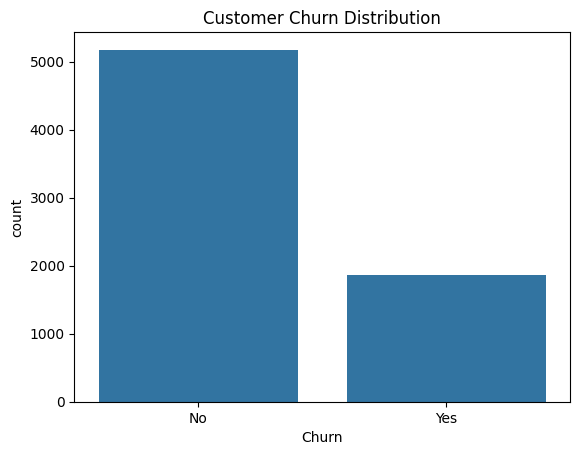

In [34]:
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()

2. Contract Type vs Churn

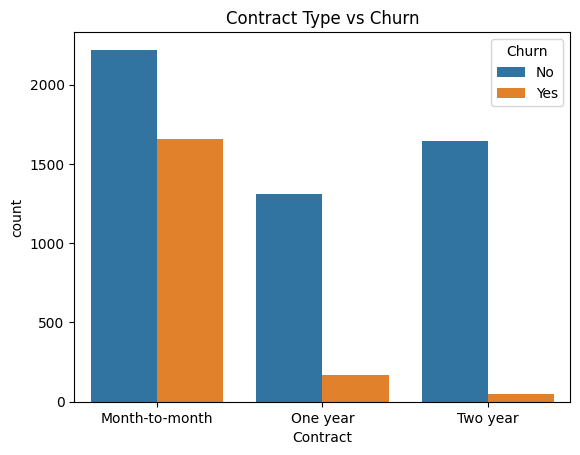

In [56]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)
plt.title('Contract Type vs Churn')
plt.show()

2.1 Observation:
    Customers with Month-to-Month contracts show the highest churn.
Customers with One-Year and Two-Year contracts have significantly lower churn rates.
Churn decreases as contract duration increases.

2.2 Business implication:
    Long-term contracts improve customer retention.
Customers without a long-term commitment are more likely to switch providers.
The company should encourage Month-to-Month customers to move to annual plans through discounts and loyalty benefits.

3. Internet Service vs Churn

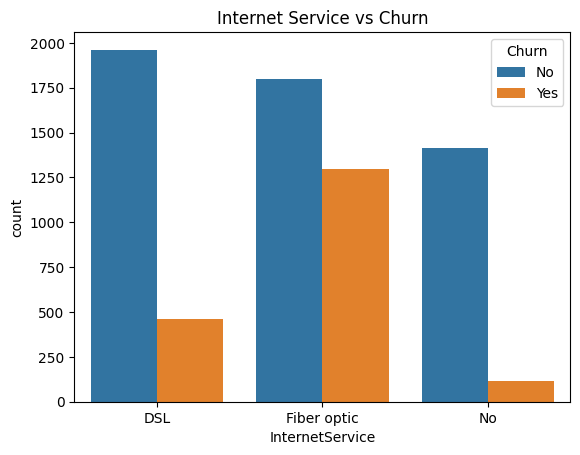

In [57]:
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)
plt.title('Internet Service vs Churn')
plt.show()

3.1 Observation: 
Customers using Fiber Optic Internet exhibit the highest churn.
DSL customers have comparatively lower churn.
Customers without internet service show the lowest churn.

3.2 Business Implication: 
Despite being a premium service, Fiber Optic customers are leaving more frequently.
Possible reasons include higher pricing, service quality issues, or unmet expectations.
Customer feedback and service-quality investigations should focus on Fiber Optic users.

4. Monthly Charges vs Churn

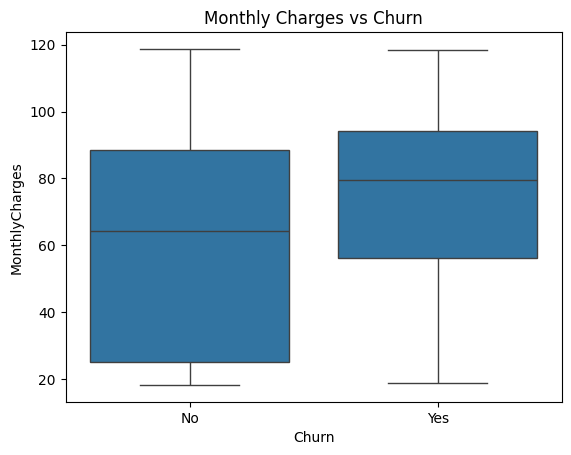

In [58]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)
plt.title('Monthly Charges vs Churn')
plt.show()

4.1 Observation: 
Customers who churn generally have higher monthly charges.
The churned customer distribution is skewed toward expensive plans.

4.2 Business Implication: 
Price sensitivity may be contributing to churn.
Customers paying more expect better value and service quality.
The company should review premium pricing strategies and provide additional benefits to high-paying customers.

5. Tenure vs Churn

Text(0.5, 1.0, 'Tenure vs Churn')

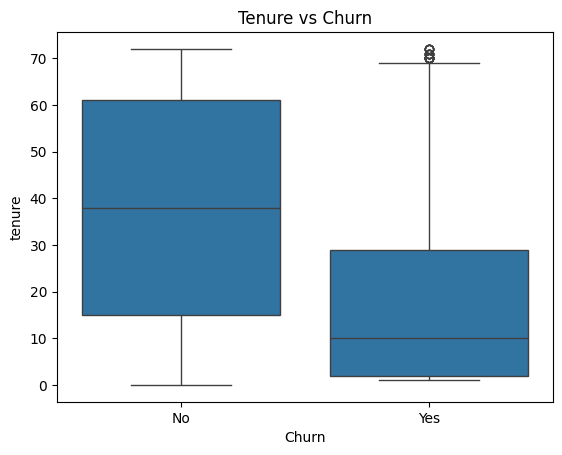

In [59]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')

5.1 Observation:
Customers with shorter tenure are much more likely to churn.
Long-tenure customers generally remain loyal.

5.2 Business Implication: 
The first year of the customer lifecycle is critical.
Onboarding and early engagement programs can significantly improve retention.

6. Payment Method vs Churn

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

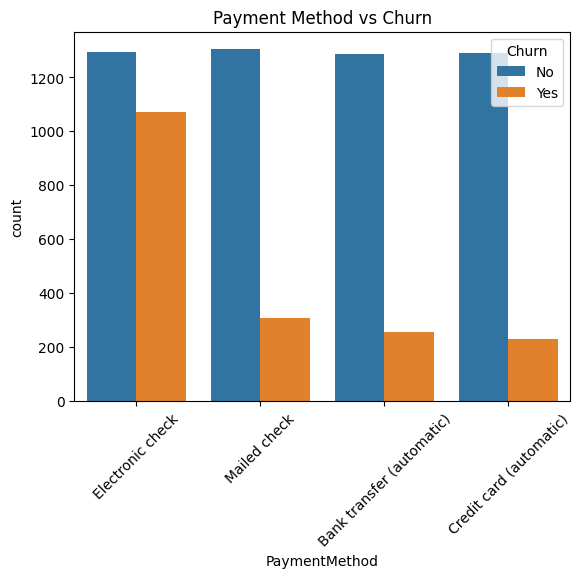

In [60]:
sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)
plt.title('Payment Method vs Churn')
plt.xticks(rotation=45)

6.1 Observation:
Customers using Electronic Check tend to churn more than customers using automatic payment methods.

6.2 Business Implication:
Automatic payment methods indicate stronger customer commitment.
Encouraging customers to enroll in auto-pay programs may improve retention.

7. Senior Citizen vs Churn

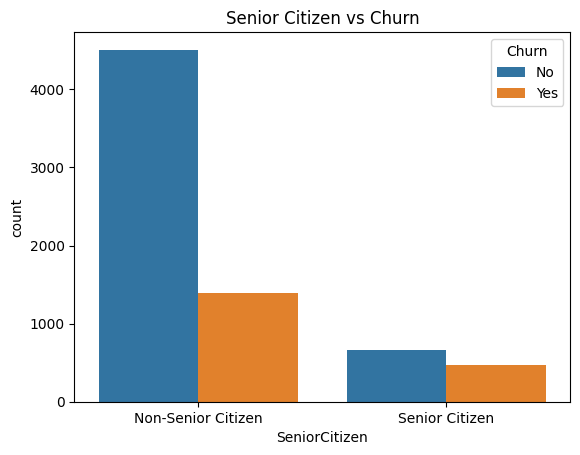

In [55]:
ax = sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)

ax.set_xticks([0, 1], ['Non-Senior Citizen', 'Senior Citizen'])

plt.title('Senior Citizen vs Churn')
plt.show()

7.1 Observation:
Senior citizens show a higher churn rate compared to non-senior customers.

7.2 Business Implication:
Senior customers may have different service expectations or affordability concerns.
Targeted support programs could help improve retention among this segment.

8. Tech Support vs Churn

Text(0.5, 1.0, 'Tech Support vs Churn')

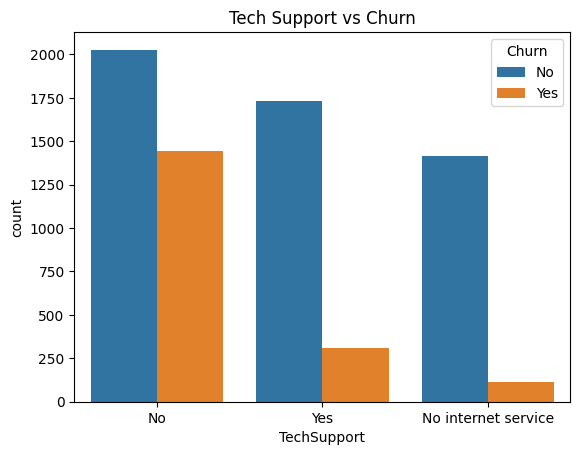

In [61]:
sns.countplot(
    x='TechSupport',
    hue='Churn',
    data=df
)
plt.title('Tech Support vs Churn')

8.1 Observation:
Customers without Tech Support churn significantly more than customers who subscribe to Tech Support.

8.2 Business Implication:
Technical assistance contributes positively to customer satisfaction.
Bundling Tech Support into service plans may reduce churn.

9. Online Security vs Churn

Text(0.5, 1.0, 'Online Security vs Churn')

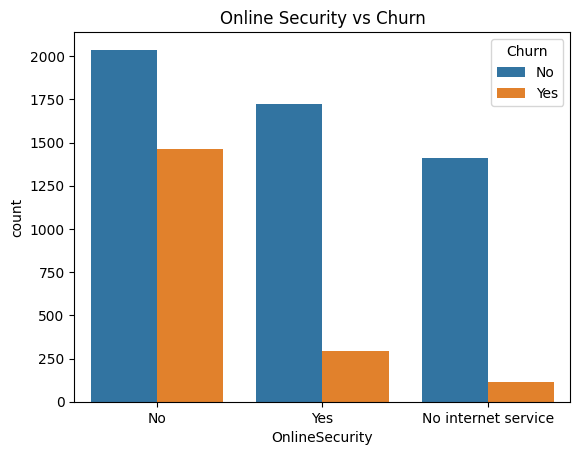

In [62]:
sns.countplot(
    x='OnlineSecurity',
    hue='Churn',
    data=df
)
plt.title('Online Security vs Churn')

9.1 Observation:
Customers without Online Security services are more likely to churn.

9.2 Business Implication: 
Value-added services increase customer stickiness.
Promoting security packages can improve retention while increasing revenue.